In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

In [10]:
df = pd.read_csv('bank-additional-full.csv', delimiter=';', decimal='.')
print(df.columns.tolist())
data = pd.get_dummies(df, columns=["job","marital","education","default","housing","loan","contact","month","day_of_week",'poutcome',])

data = data.dropna(axis=1, how='all')  
data.fillna(data.mean(numeric_only=True), inplace=True)
X = data.drop(['y'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(data['y'].values)
 

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

print(pd.Series(y).value_counts())



# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

scaler = StandardScaler()
X = scaler.fit_transform(X)
# X_test = scaler.transform(X_test)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Признаков: 63, Объектов: 41188
0    36548
1     4640
Name: count, dtype: int64


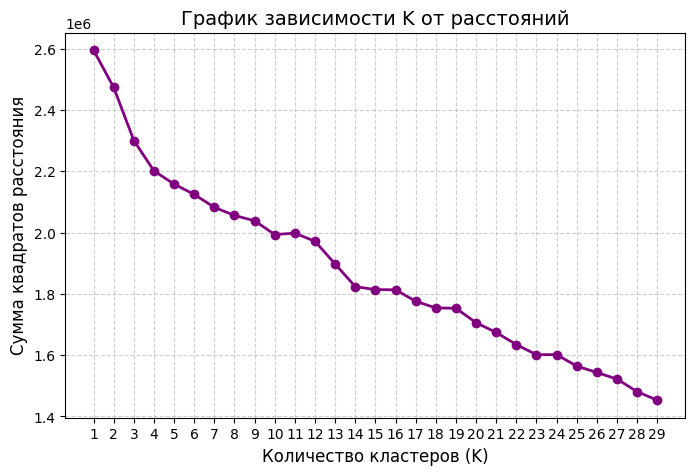

In [11]:
mean_distances = []
k_range = range(1, 30)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    mean_distances.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, mean_distances, marker='o', color='purple', linestyle='-', linewidth=2)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Сумма квадратов расстояния', fontsize=12)
plt.title('График зависимости K от расстояний', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans.fit(X)
labels_kmeans = kmeans.labels_

score = kmeans.score(X)
print(f"Score: {score:.2f}")
for i in range(14):
    print(f"Кластер {i}: {np.sum(labels_kmeans==i)} объектов")


Score: -2300258.36
Кластер 0: 15158 объектов
Кластер 1: 1518 объектов
Кластер 2: 24512 объектов
Кластер 3: 0 объектов
Кластер 4: 0 объектов
Кластер 5: 0 объектов
Кластер 6: 0 объектов
Кластер 7: 0 объектов
Кластер 8: 0 объектов
Кластер 9: 0 объектов
Кластер 10: 0 объектов
Кластер 11: 0 объектов
Кластер 12: 0 объектов
Кластер 13: 0 объектов


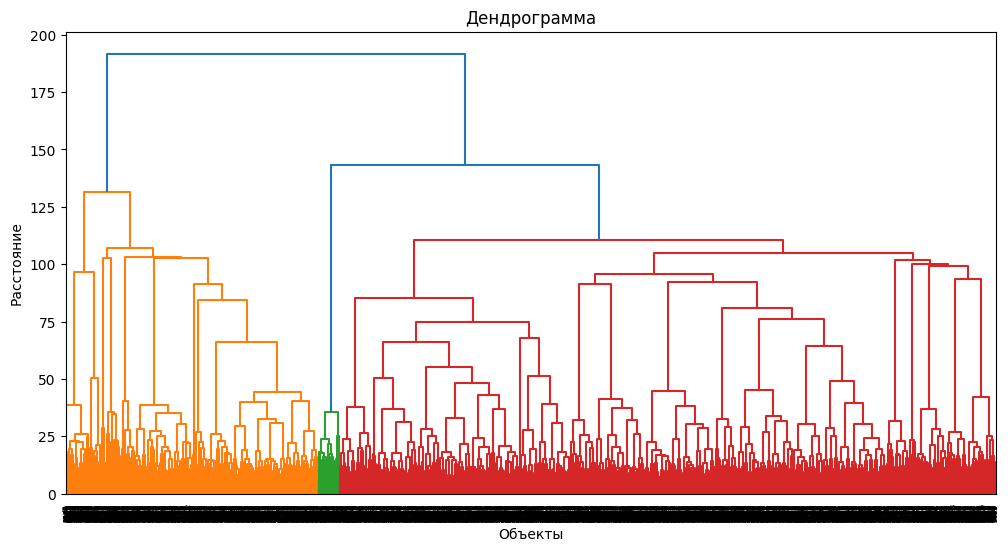

Кластер 0: 1359 объектов
Кластер 1: 3528 объектов
Кластер 2: 113 объектов


In [13]:
X_sample = resample(X, n_samples=5000, random_state=42, replace=False)
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Дендрограмма')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_sample)

for i in range(3):
    print(f"Кластер {i}: {np.sum(labels==i)} объектов")

Pavels DBSCAN 

In [14]:
clustering = DBSCAN(eps=9, min_samples=10).fit(X)
labels = clustering.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

for cluster in np.unique(labels):
    if cluster == -1:
        continue

    print(f"\nCluster {cluster}")
    print(X[labels == cluster].mean(axis=0))

Estimated number of clusters: 7
Estimated number of noise points: 123

Cluster 0
[-0.00891795 -0.00147931  0.00215839  0.01578395 -0.01374828  0.02329901
  0.01386692 -0.00423061  0.02483652  0.02927347  0.00474945  0.00929914
  0.00427391  0.00056288  0.00232105 -0.00736905 -0.00069596  0.00615821
 -0.00710453  0.00432874 -0.00130184 -0.08987076  0.00170852  0.00545926
 -0.00281462 -0.04411455 -0.00248955  0.0020996   0.00482446  0.00534722
 -0.0209096   0.00111209 -0.00070592 -0.01645863 -0.00176487  0.00194432
 -0.00853476  0.02402287 -0.1569334   0.02418729  0.05359611 -0.1569334
  0.01014129 -0.00336148  0.00336148  0.00662215  0.00799513 -0.06662113
  0.01084702  0.00193389 -0.11590677  0.0113233   0.00972626  0.00037237
  0.00116054  0.00217214 -0.00248985  0.00101969 -0.00291104  0.00225502
 -0.00483296  0.0121404  -0.01503216]

Cluster 1
[ 5.22719079e-01 -8.23147569e-02  5.27845745e-02 -3.74912610e-02
 -1.11372863e-01  2.83516262e-01  3.38220756e-01  2.76432322e-01
  2.7816497

In [15]:
for cluster in np.unique(labels):
    if cluster == -1:
        continue

    print(f"\nCluster {cluster}")

    mean = X[labels == cluster].mean(axis=0)

    for i, value in enumerate(mean):
        print(f"Feature {i:2d}: {value:.3f}")
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")


Cluster 0
Feature  0: -0.009
Feature  1: -0.001
Feature  2: 0.002
Feature  3: 0.016
Feature  4: -0.014
Feature  5: 0.023
Feature  6: 0.014
Feature  7: -0.004
Feature  8: 0.025
Feature  9: 0.029
Feature 10: 0.005
Feature 11: 0.009
Feature 12: 0.004
Feature 13: 0.001
Feature 14: 0.002
Feature 15: -0.007
Feature 16: -0.001
Feature 17: 0.006
Feature 18: -0.007
Feature 19: 0.004
Feature 20: -0.001
Feature 21: -0.090
Feature 22: 0.002
Feature 23: 0.005
Feature 24: -0.003
Feature 25: -0.044
Feature 26: -0.002
Feature 27: 0.002
Feature 28: 0.005
Feature 29: 0.005
Feature 30: -0.021
Feature 31: 0.001
Feature 32: -0.001
Feature 33: -0.016
Feature 34: -0.002
Feature 35: 0.002
Feature 36: -0.009
Feature 37: 0.024
Feature 38: -0.157
Feature 39: 0.024
Feature 40: 0.054
Feature 41: -0.157
Feature 42: 0.010
Feature 43: -0.003
Feature 44: 0.003
Feature 45: 0.007
Feature 46: 0.008
Feature 47: -0.067
Feature 48: 0.011
Feature 49: 0.002
Feature 50: -0.116
Feature 51: 0.011
Feature 52: 0.010
Feature 53: 0

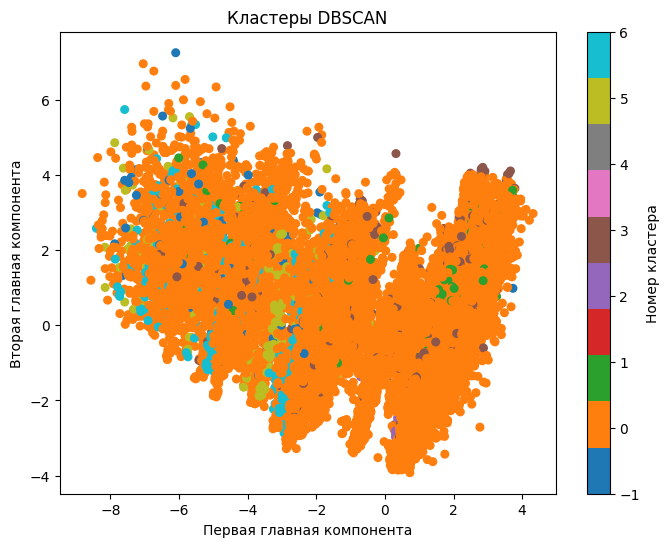

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='tab10',
    s=30
)

plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Кластеры DBSCAN")
plt.colorbar(label="Номер кластера")
plt.show()

In [28]:
def analyze_cluster_features(X, labels, feature_names=None, n_top=10):
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    
    df = pd.DataFrame(X, columns=feature_names)
    df['cluster'] = labels
    
    if -1 in labels:
        df = df[df['cluster'] != -1]
        print(f"Удалено шумовых точек: {np.sum(labels == -1)}")
    
    clusters = sorted(df['cluster'].unique())
    n_clusters = len(clusters)
    
    print(f"АНАЛИЗ ПРИЗНАКОВ ДЛЯ {n_clusters} КЛАСТЕРОВ")
    
    X_clean = df.drop('cluster', axis=1).values
    y_clean = df['cluster'].values
    
    f_scores, p_values = f_classif(X_clean, y_clean)
    
    feature_importance = pd.DataFrame({
        'Признак': feature_names,
        'F-статистика': f_scores,
        'p-значение': p_values
    }).sort_values('F-статистика', ascending=False)
    
    print("ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):")
    print(feature_importance.head(n_top).to_string(index=False))
    
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(n_top)
    plt.barh(top_features['Признак'], top_features['F-статистика'], color='skyblue')
    plt.xlabel('F-статистика')
    plt.title('Топ признаков, разделяющих кластеры')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    cluster_means = df.groupby('cluster').mean()
    
    cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()
    
    plt.figure(figsize=(14, max(6, n_clusters * 0.6)))
    sns.heatmap(
        cluster_means_norm[feature_importance.head(n_top)['Признак'].tolist()],
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        cbar_kws={'label': 'Отклонение от среднего (в std)'}
    )
    plt.title('Средние значения топ-признаков по кластерам')
    plt.xlabel('Признаки')
    plt.ylabel('Кластер')
    plt.tight_layout()
    plt.show()
    
    global_mean = df.drop('cluster', axis=1).mean()
    
    print("ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:")
    
    for cluster in clusters:
        size = np.sum(df['cluster'] == cluster)
        cluster_mean = cluster_means.loc[cluster]
        deviation = cluster_mean - global_mean
        
        top_high = deviation.nlargest(3)
        top_low = deviation.nsmallest(3)
        
        print(f"КЛАСТЕР {cluster} (n={size}, {size/len(df)*100:.1f}%)")
        
        if not top_high.empty:
            print("  ВЫШЕ СРЕДНЕГО:")
            for feat, val in top_high.items():
                print(f"    {feat}: +{val:.3f}")
        
        if not top_low.empty:
            print("  НИЖЕ СРЕДНЕГО:")
            for feat, val in top_low.items():
                print(f"    {feat}: {val:.3f}")
    
    return feature_importance, cluster_means

Всего признаков: 63
АНАЛИЗ ПРИЗНАКОВ ДЛЯ 3 КЛАСТЕРОВ
ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):
             Признак  F-статистика  p-значение
               pdays  9.941358e+06         0.0
    poutcome_success  1.878033e+05         0.0
        emp.var.rate  1.149983e+05         0.0
           euribor3m  9.171486e+04         0.0
         nr.employed  4.782794e+04         0.0
      cons.price.idx  2.509308e+04         0.0
            previous  1.579905e+04         0.0
poutcome_nonexistent  1.280969e+04         0.0
    contact_cellular  6.286979e+03         0.0
   contact_telephone  6.286979e+03         0.0


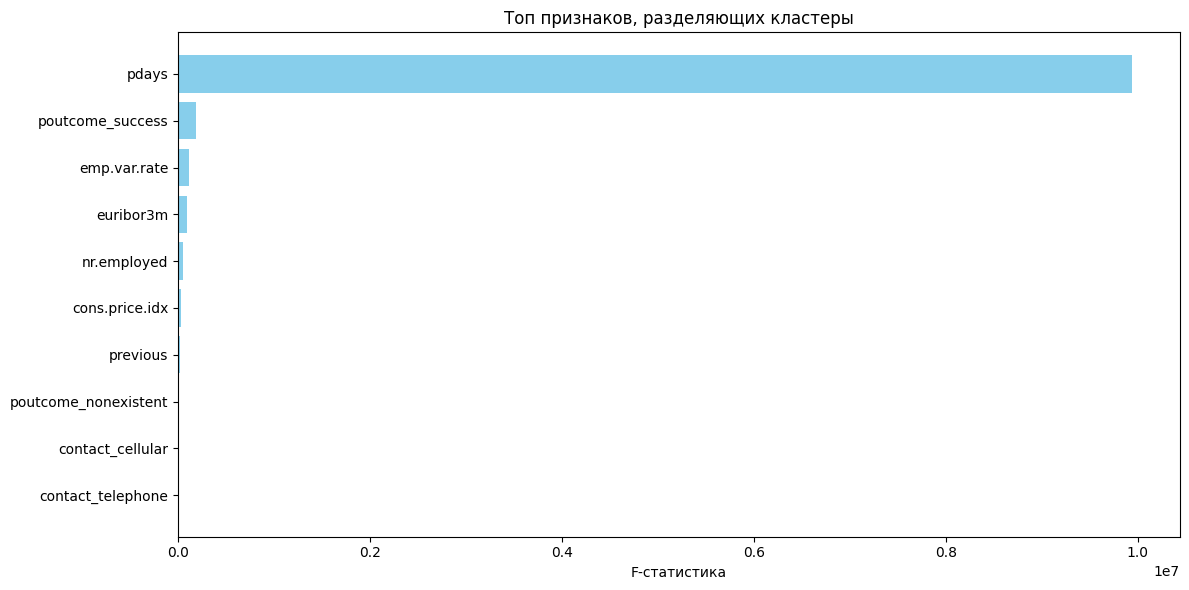

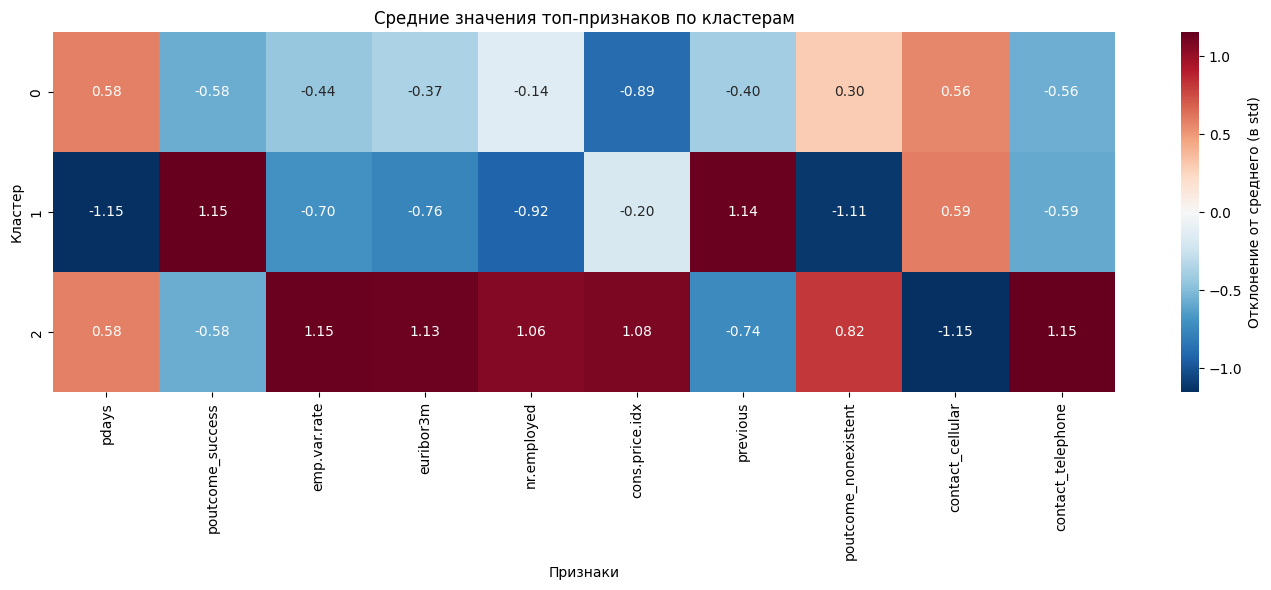

ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:
КЛАСТЕР 0 (n=15158, 36.8%)
  ВЫШЕ СРЕДНЕГО:
    contact_cellular: +0.585
    poutcome_failure: +0.551
    month_nov: +0.431
  НИЖЕ СРЕДНЕГО:
    emp.var.rate: -1.087
    euribor3m: -1.048
    cons.price.idx: -0.940
КЛАСТЕР 1 (n=1518, 3.7%)
  ВЫШЕ СРЕДНЕГО:
    poutcome_success: +4.853
    previous: +3.020
    month_sep: +0.801
  НИЖЕ СРЕДНЕГО:
    pdays: -5.107
    poutcome_nonexistent: -2.514
    nr.employed: -1.909
КЛАСТЕР 2 (n=24512, 59.5%)
  ВЫШЕ СРЕДНЕГО:
    emp.var.rate: +0.758
    euribor3m: +0.742
    nr.employed: +0.672
  НИЖЕ СРЕДНЕГО:
    contact_cellular: -0.399
    previous: -0.349
    poutcome_failure: -0.339


In [29]:
feature_names = data.drop(['y'], axis=1).columns.tolist()

print(f"Всего признаков: {len(feature_names)}")

importance_kmeans, means_kmeans = analyze_cluster_features(
    X,           
    labels_kmeans,  
    feature_names,
    n_top=10
)





Удалено шумовых точек: 123
АНАЛИЗ ПРИЗНАКОВ ДЛЯ 7 КЛАСТЕРОВ
ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):
          Признак  F-статистика    p-значение
        month_dec  3.682914e+19  0.000000e+00
        month_mar  1.662450e+17  0.000000e+00
          loan_no  8.411223e+02  0.000000e+00
      nr.employed  3.377837e+02  0.000000e+00
        euribor3m  2.698740e+02  0.000000e+00
     emp.var.rate  2.446946e+02 1.446703e-308
      housing_yes  1.815981e+02 4.306333e-229
education_unknown  1.605481e+02 1.935432e-202
   cons.price.idx  1.373466e+02 5.487269e-173
       housing_no  1.359191e+02 3.580051e-171


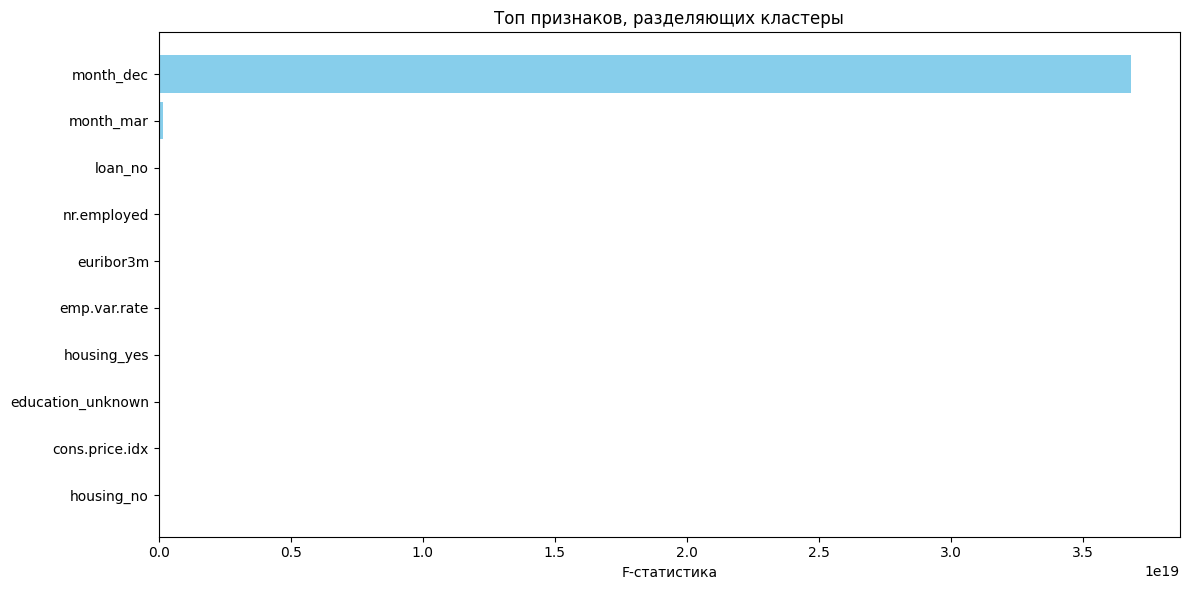

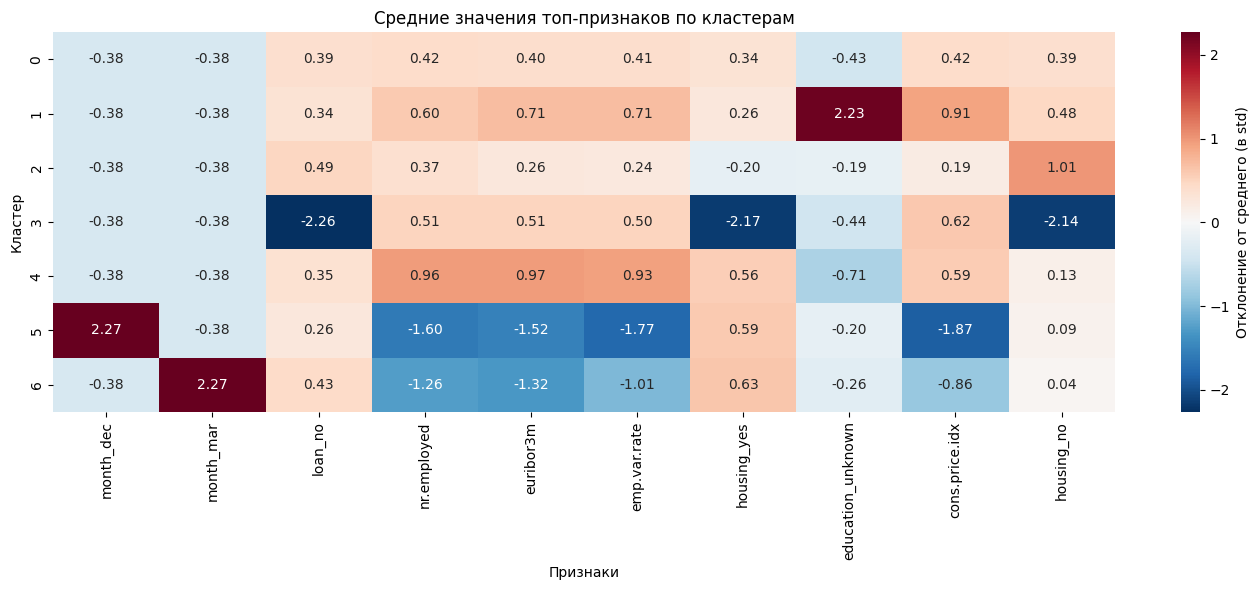

ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:
КЛАСТЕР 0 (n=39071, 95.1%)
  ВЫШЕ СРЕДНЕГО:
    loan_no: +0.050
    nr.employed: +0.025
    housing_yes: +0.023
  НИЖЕ СРЕДНЕГО:
    housing_unknown: -0.148
    loan_unknown: -0.148
    month_mar: -0.112
КЛАСТЕР 1 (n=297, 0.7%)
  ВЫШЕ СРЕДНЕГО:
    job_unknown: +11.136
    education_unknown: +1.756
    default_unknown: +0.679
  НИЖЕ СРЕДНЕГО:
    default_no: -0.679
    job_admin.: -0.583
    job_blue-collar: -0.539
КЛАСТЕР 2 (n=57, 0.1%)
  ВЫШЕ СРЕДНЕГО:
    marital_unknown: +22.681
    month_may: +0.294
    job_self-employed: +0.292
  НИЖЕ СРЕДНЕГО:
    marital_married: -1.239
    marital_single: -0.625
    marital_divorced: -0.355
КЛАСТЕР 3 (n=928, 2.3%)
  ВЫШЕ СРЕДНЕГО:
    housing_unknown: +6.382
    loan_unknown: +6.382
    month_jun: +0.176
  НИЖЕ СРЕДНЕГО:
    loan_no: -2.169
    housing_yes: -1.050
    housing_no: -0.910
КЛАСТЕР 4 (n=12, 0.0%)
  ВЫШЕ СРЕДНЕГО:
    education_illiterate: +47.832
    job_blue-collar: +1.058
    age: +0.742
  НИЖЕ СРЕДНЕГ

In [30]:
importance_dbscan, means_dbscan = analyze_cluster_features(
    X,
    labels,  
    feature_names,
    n_top=10
)

